# Taxonomic Distributions & Sample Generator

This notebook generates phylum stratified samples and summarizes how samples are distributed across `taxon_phylum` and `taxon_class` to ensure samples are representative of the original `dataset.csv`. 

## Setup

In [607]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


def load_data(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'{path} not found')
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.replace('_name$', '', regex=True)
    print(f'Read {len(df):,} rows and {len(df.columns)} columns from {path.name}')
    return df

def get_counts(df, column):
    counts = (
        df[column]
        .fillna('Unknown')
        .astype(str)
        .value_counts()
        .reset_index(name='count')
        .rename(columns={'index': column})
    )
    counts['percent'] = 100 * counts['count'] / len(df)
    return counts

def plot_counts(counts, column, label, color='#3182bd'):
    fig, ax = plt.subplots(figsize=(7, len(counts) * 0.20))
    bars = ax.barh(counts[column], counts['count'], color=color)
    ax.set_xlabel('Observation count')
    ax.set_title(f"{label} observations per {column.replace('taxon_', '')}")
    ax.invert_yaxis()
    ax.tick_params(labelsize=7)
    ax.bar_label(bars, fmt='%d', padding=2)
    plt.tight_layout()


def phylum_report(df, label):
    counts = get_counts(df, 'taxon_phylum')
    plot_counts(counts, 'taxon_phylum', label, '#3182bd')

def class_report(df, label):
    counts = get_counts(df, 'taxon_class')
    plot_counts(counts, 'taxon_class', label, '#2ca02c')

sample_1x = '../data/sample_1x.csv'
sample_3x = '../data/sample_3x.csv'


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Original dataset

In [608]:
df = load_data('../data/dataset.csv')
df.info()

Read 10,330 rows and 71 columns from dataset.csv
<class 'pandas.DataFrame'>
RangeIndex: 10330 entries, 0 to 10329
Data columns (total 71 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   id                                                           10330 non-null  int64  
 1   uuid                                                         10330 non-null  str    
 2   observed_on_string                                           10329 non-null  str    
 3   observed_on                                                  10329 non-null  str    
 4   time_observed_at                                             9746 non-null   str    
 5   time_zone                                                    10330 non-null  str    
 6   user_id                                                      10330 non-null  int64  
 7   user_login                            

## Phylum counts

Compute the number and percentage of observations that fall into each phylum.

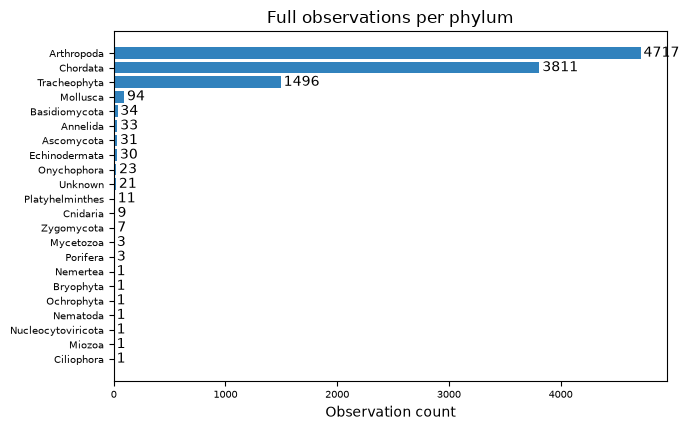

In [609]:
phylum_report(df, "Full")

## Class counts

Compute the number and percentage of observations that fall into each class.

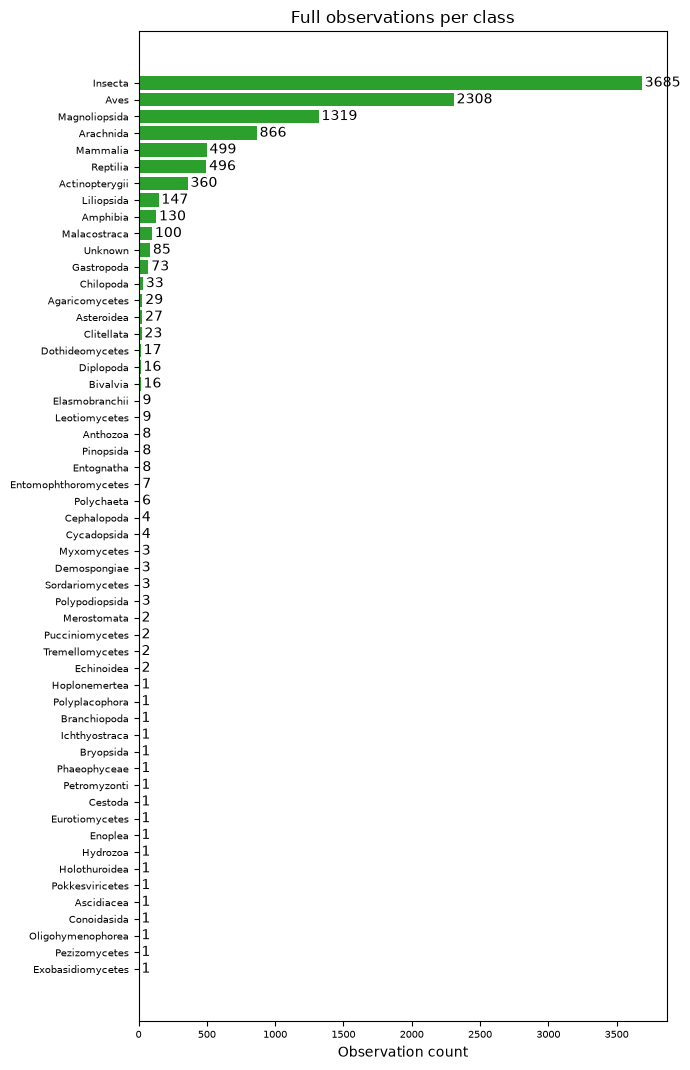

In [610]:
class_report(df, "Full")

## Cleaned Dataset

Keep only **research-grade**, **licensed** observations, then within each phylum drop
duplicate `class / order / family / genus` combinations so every row is a distinct
lineage. This is the pool the samples are drawn from.

In [611]:
# data after dropping duplicates, non-research-grade, and n/a licensing
phylum_cols = ['taxon_class', 'taxon_order', 'taxon_family', 'taxon_genus']
sample = []
for phylum in sorted(df['taxon_phylum'].dropna().unique()):
    phylum_df = df[df['taxon_phylum'] == phylum]
    phylum_df = phylum_df[phylum_df['quality_grade'] == 'research']
    phylum_df = phylum_df[phylum_df['license'].notna()]
    phylum_unique = (
        phylum_df
        .drop_duplicates(subset=phylum_cols)
        .head(21)
        .reset_index(drop=True)
    )
    sample.append(phylum_unique)
    print(
        f"Showing {len(phylum_unique)} {phylum} entries with distinct class/order/family/genus combos."
    )
sample_df = pd.concat(sample, ignore_index=True)
output_path = Path('../data/sample_3x_research_grade.csv')
output_path.parent.mkdir(exist_ok=True)

Showing 4 Annelida entries with distinct class/order/family/genus combos.
Showing 21 Arthropoda entries with distinct class/order/family/genus combos.
Showing 4 Ascomycota entries with distinct class/order/family/genus combos.
Showing 8 Basidiomycota entries with distinct class/order/family/genus combos.
Showing 0 Bryophyta entries with distinct class/order/family/genus combos.
Showing 21 Chordata entries with distinct class/order/family/genus combos.
Showing 0 Ciliophora entries with distinct class/order/family/genus combos.
Showing 2 Cnidaria entries with distinct class/order/family/genus combos.
Showing 6 Echinodermata entries with distinct class/order/family/genus combos.
Showing 0 Miozoa entries with distinct class/order/family/genus combos.
Showing 21 Mollusca entries with distinct class/order/family/genus combos.
Showing 2 Mycetozoa entries with distinct class/order/family/genus combos.
Showing 0 Nematoda entries with distinct class/order/family/genus combos.
Showing 0 Nemertea 

In [612]:
sample_df.shape

(119, 71)

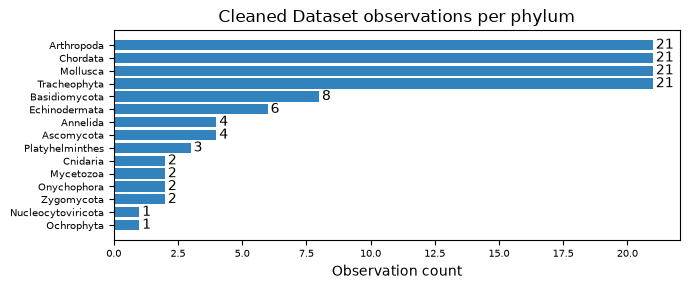

In [613]:
phylum_report(sample_df, "Cleaned Dataset")

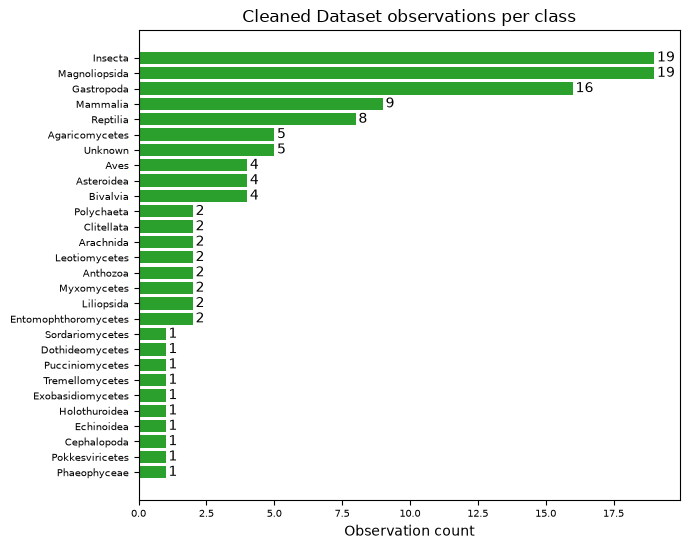

In [614]:
class_report(sample_df, "Cleaned Dataset")

## Sample generator

`write_sample` standardizes the headers to the sample schema.

In [615]:
def sample(size, output_path_name):
    phylum_cols = ['taxon_class', 'taxon_order', 'taxon_family', 'taxon_genus']
    sample = []
    for phylum in sorted(df['taxon_phylum'].dropna().unique()):
        phylum_df = df[df['taxon_phylum'] == phylum]
        phylum_df = phylum_df[phylum_df['quality_grade'] == 'research']
        phylum_df = phylum_df[phylum_df['license'].notna()]
        phylum_unique = (
            phylum_df
            .drop_duplicates(subset=phylum_cols)
            .head(size)
            .reset_index(drop=True)
        )
        sample.append(phylum_unique)
        print(
            f"Showing {len(phylum_unique)} {phylum} entries with distinct class/order/family/genus combos."
        )
    sample_df = pd.concat(sample, ignore_index=True)
    return sample_df

def write_sample(sample_df, file_name):
    output_path = Path(f'../data/{file_name}.csv')
    output_path.parent.mkdir(exist_ok=True)
    # standardize column headers
    sample_df["photo_id"] = sample_df["image_url"].str.extract(r"/photos/(\d+)", expand=False)
    sample_df = sample_df.rename(columns={
        "id":        "observation_id",
        "url":       "uri",
        "image_url": "medium_url",
        "scientific":"scientific_name",
        "common": "common_name"
    })
    # Image_name column
    sample_df["Image_name"] = (
        "obs_" + sample_df["observation_id"].astype(str) + "_photo_" + sample_df["photo_id"].astype(str)
    )
    sample_df.to_csv(file_name, index=False)

## Sample 1x Distribution

**1x** keeps up to **7** distinct combos per phylum.


In [616]:
df_1x = load_data(sample_1x)
df_1x.head(3)

Read 63 rows and 31 columns from sample_1x.csv


,observation_id,photo_id,Image,GroundingDino_V.1_Detected?,V.1 Analysis,GroundingDino_V.2_Detected?,V.2 Analysis,license_code,sam2+bioclip classification v.3,v3. Analysis,...,uri,pred_prey,special_type_of_feeding,taxon_kingdom,taxon_phylum,taxon_class,taxon_order,taxon_family,taxon_genus,taxon_species
0,102691691,171703626,obs_102691691_photo_171703626,Maybe,Tiny part of the box,Yes,Visible,cc-by-nc,True,NaN,...,https://www.inaturalist.org/observations/10269...,Prey,Predation,Chromista,Ochrophyta,Phaeophyceae,Laminariales,Lessoniaceae,Egregia,Egregia menziesii
1,10317797,14298032,obs_10317797_photo_14298032,Maybe,Tiny part of the box,Yes,Visible,cc-by-nc,False,Prey and predator both in the picture. Leather...,...,https://www.inaturalist.org/observations/10317797,Prey,Predation,Animalia,Echinodermata,Asteroidea,Valvatida,Asteropseidae,Dermasterias,Dermasterias imbricata
2,130480768,70327211,obs_130480768_photo_70327211,Maybe,Tiny part of the box,Yes,Visible,cc-by,False,NaN,...,https://www.inaturalist.org/observations/13048...,Pred,Parasitism,Animalia,Annelida,Clitellata,Arhynchobdellida,Hirudinidae,Hirudo,Hirudo michaelseni


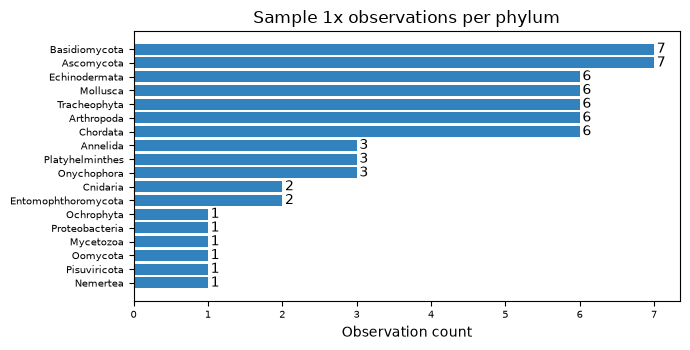

In [617]:
phylum_report(df_1x, "Sample 1x")

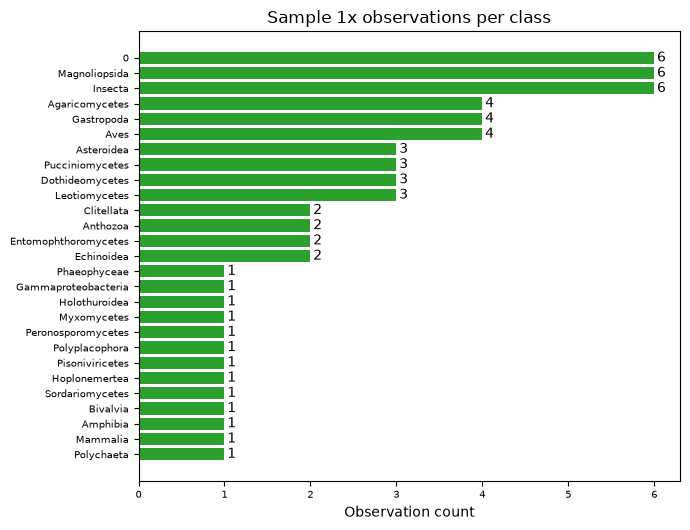

In [618]:
class_report(df_1x, "Sample 1x")

## Sample 3x Distribution
**1x** keeps up to **21** distinct combos per phylum.

In [619]:
df_3x = load_data(sample_3x)
df_3x.head(3)

Read 167 rows and 15 columns from sample_3x.csv


,observation_id,photo_id,Image,medium_url,scientific,common,quality_grade,uri,taxon_kingdom,taxon_phylum,taxon_class,taxon_order,taxon_family,taxon_genus,taxon_species
0,33435757,52514997,obs_33435757_photo_52514997,https://inaturalist-open-data.s3.amazonaws.com...,Nereididae,Ragworms and Allies,needs_id,https://www.inaturalist.org/observations/33435757,Animalia,Annelida,Polychaeta,Phyllodocida,Nereididae,NaN,NaN
1,54130547,86113964,obs_54130547_photo_86113964,https://inaturalist-open-data.s3.amazonaws.com...,Lumbricidae,Lumbricid Earthworms,needs_id,https://www.inaturalist.org/observations/54130547,Animalia,Annelida,Clitellata,Crassiclitellata,Lumbricidae,NaN,NaN
2,55364509,88154142,obs_55364509_photo_88154142,https://inaturalist-open-data.s3.amazonaws.com...,Haemadipsa trimaculosa,NaN,needs_id,https://www.inaturalist.org/observations/55364509,Animalia,Annelida,Clitellata,Arhynchobdellida,Haemadipsidae,Haemadipsa,Haemadipsa trimaculosa


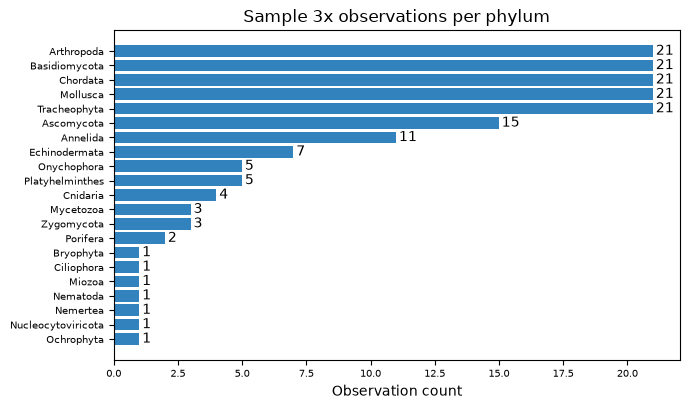

In [620]:
phylum_report(df_3x, "Sample 3x")

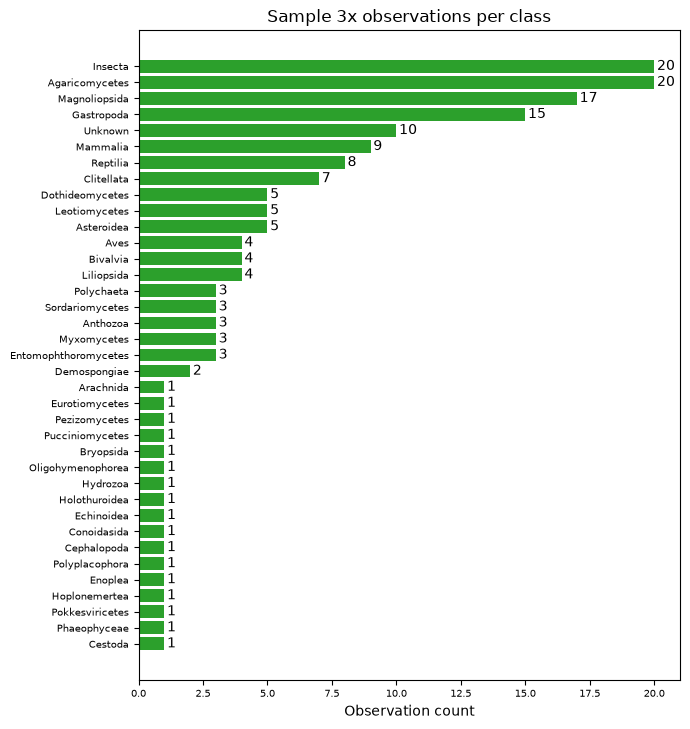

In [621]:
class_report(df_3x, "Sample 3x")

In [622]:
# reference
# column_order = [
    #     "observation_id",
    #     "photo_id",
    #     "Image_name",
    #     "medium_url",
    #     "scientific_name",
    #     "common_name",
    #     "quality_grade",
    #     "uri",
    #     "taxon_kingdom",
    #     "taxon_phylum",
    #     "taxon_class",
    #     "taxon_order",
    #     "taxon_family",
    #     "taxon_genus",
    #     "taxon_species"
    # ]
    # sample_df = sample_df[[c for c in column_order if c in sample_df.columns]]